# Student Credit Risk Assessment
## Support Vector Machine Baseline

This notebook develops the Support Vector Machine baseline model for the Student Credit Risk Assessment project. It uses the final post-EDA dataset and serves as the reference model for evaluating subsequent machine learning approaches.

## 1. Project Context



This notebook develops the **Support Vector Machine baseline model** for the Student Credit Risk Assessment project using the final post-EDA modelling dataset. As the first baseline model in the research pipeline, it establishes an interpretable benchmark against which subsequent machine learning models and the Nemotron reasoning model can be systematically evaluated.





### 1.1 Problem Statement



Financial institutions often encounter **thin-file borrowers**, particularly students with limited credit histories, making conventional credit risk assessment challenging. Inaccurate risk estimation may result in increased default rates, reduced financial inclusion, or overly conservative lending practices.

This notebook addresses the binary classification problem of predicting whether a borrower is likely to default (`default_flag`) using demographic, academic, financial, behavioural, and banking-related features derived during the data generation and exploratory data analysis stages.





### 1.2 Why Support Vector Machine?


Support Vector Machine (SVM) is selected as the second baseline model to investigate whether a margin-based classifier can better separate default and non-default students within the engineered feature space.

Unlike Logistic Regression, which models a linear decision boundary through probability estimation, SVM constructs an optimal separating hyperplane by maximising the margin between classes. This property enables SVM to capture more complex decision boundaries, particularly when combined with appropriate kernel functions.

Evaluating SVM under the same experimental protocol allows a direct comparison with Logistic Regression while maintaining identical feature engineering, preprocessing and evaluation procedures.



### 1.3 Research Objectives

The primary objectives of this notebook are to:

- Develop and evaluate a reproducible Support Vector Machine baseline for student credit risk prediction.
- Evaluate model performance under three experimental data-splitting strategies.
- Compare baseline and hyperparameter-tuned model performance.
- Analyse feature contributions using coefficient interpretation and SHAP explanations.
- Assess fairness across selected demographic groups.
- Compare the behaviour of Support Vector Machine with the Nemotron reasoning model.





### 1.4 Expected Outcomes

By the completion of this notebook, the following outcomes are expected:

-   A validated Support Vector Machine baseline model.
- Performance evaluation across three experimental strategies.
- Comparative analysis between baseline and tuned configurations.
- Identification of influential predictive features.
- Assessment of model interpretability and fairness.
- Comparative insights against the Nemotron reasoning model.



## 2. Dataset Foundation

This section loads and verifies the final modelling dataset before feature selection and preprocessing. The objective is to confirm that the dataset has been imported correctly, follows the expected schema, and is ready for subsequent modelling stages.

### 2.1 Import Libraries

In [1]:
# ==========================================================
# 2.1 Import Libraries
# ==========================================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("default")
sns.set_theme(style="whitegrid")

### 2.2 Load Dataset

In [2]:
# ==========================================================
# 2.2 Load Dataset
# ==========================================================

DATA_PATH = "../data/master_v6_post_eda.csv"

TARGET_COLUMN = "default_flag"

IDENTIFIER_COLUMNS = [
    "student_id"
]

LEAKAGE_COLUMNS = [
    "default_probability"
]

RANDOM_STATE = 42

student_df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {student_df.shape}")

display(student_df.head())

Dataset Shape : (21000, 38)


,student_id,synthetic_age,enrollment_type,academic_year,major_category,gpa_direction,credit_hours_current,semesters_enrolled,expected_total_semesters,remaining_semesters,monthly_inflow_mean,cash_flow_cv,aid_disbursement_flag,aid_amount,estimated_tuition,estimated_living_cost,synthetic_debt_load,campus_employment,gig_income_flag,bill_payment_rate,savings_behavior,subscription_count,prior_delinquency,application_week,semester_phase,academic_calendar_flag,ecs,gdi,acr,cfri,opr,tgb,spra,sei,default_probability,default_flag,credit_bin,synthetic_anomaly_flag
0,STU_002313,21.9141,Full-time,2,Business,Stable,13.3372,4,8,4,993.4006,0.7318,0,0.0000,4636.5845,6660.3798,6640.0101,0,1,0.8795,Sporadic,3,0,9,Early,1,0.5000,0.0000,0.3517,0.2682,0.8795,0.1829,0.3289,0.3259,0.0341,0,12-15 (Full),0
1,STU_016846,22.0878,Full-time,3,Arts,Stable,16.3653,5,8,3,2834.8034,0.1298,1,4725.6159,8071.4889,3797.3567,12767.0852,0,1,0.6724,Sporadic,0,0,6,Late,1,0.6250,0.0000,1.3535,0.8702,0.6724,0.1466,0.1502,0.8643,0.0046,0,15+ (Overload),0
2,STU_006106,23.4131,Full-time,2,Business,Stable,17.8260,4,8,4,530.2470,0.1648,1,6628.3747,6700.1349,3990.6708,5113.1182,0,0,0.8811,Sporadic,2,0,10,Early,1,0.5000,0.0000,0.8184,0.8352,0.8811,0.1885,0.1016,0.5592,0.0042,0,15+ (Overload),0
3,STU_018083,20.7062,Full-time,2,STEM,Stable,15.0142,3,8,5,959.2160,0.0678,1,3527.0611,8437.0759,5858.2115,5245.2304,0,1,0.9265,No Savings,2,0,5,Mid,1,0.3750,0.0000,0.5151,0.9322,0.9265,0.2092,0.0492,0.3701,0.0062,0,15+ (Overload),0
4,STU_011336,19.7460,Part-time,2,Business,Declining,7.0056,3,10,7,1475.7728,0.2107,0,0.0000,7062.3194,4216.9331,6813.0712,1,0,0.8544,Sporadic,5,0,4,Mid,1,0.3000,-1.0000,0.5234,0.7893,0.8544,0.2356,0.1279,0.1517,0.0881,0,6-11 (Half),0


### 2.3 Dataset Overview

In [3]:
# ==========================================================
# 2.3 Dataset Overview
# ==========================================================

display(student_df.describe().T)

display(student_df.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
synthetic_age,21000.0000,21.5256,1.7602,18.0000,20.2972,21.5093,22.7265,29.5624
academic_year,21000.0000,2.4066,1.0111,1.0000,2.0000,2.0000,3.0000,4.0000
credit_hours_current,21000.0000,13.4476,2.7659,3.0000,12.0000,13.7395,15.3322,19.0000
semesters_enrolled,21000.0000,4.2355,1.9720,1.0000,3.0000,4.0000,6.0000,8.0000
expected_total_semesters,21000.0000,8.4166,1.0692,8.0000,8.0000,8.0000,8.0000,12.0000
remaining_semesters,21000.0000,4.1811,2.2257,1.0000,2.0000,4.0000,6.0000,11.0000
monthly_inflow_mean,21000.0000,1314.3130,544.8404,265.6408,925.7381,1210.8788,1591.7095,7516.4249
cash_flow_cv,21000.0000,0.2849,0.1595,0.0026,0.1611,0.2642,0.3870,0.9055
aid_disbursement_flag,21000.0000,0.6489,0.4773,0.0000,0.0000,1.0000,1.0000,1.0000
aid_amount,21000.0000,3080.9336,2599.2379,0.0000,0.0000,3268.6793,5363.0736,7499.9704


,count,unique,top,freq
student_id,21000,21000,STU_002313,1
enrollment_type,21000,2,Full-time,17895
major_category,21000,4,STEM,8340
gpa_direction,21000,3,Stable,9453
savings_behavior,21000,3,Sporadic,9413
semester_phase,21000,3,Mid,10598
credit_bin,21000,4,12-15 (Full),11619


### 2.4 Dataset Structure

In [4]:
# ==========================================================
# 2.4 Dataset Structure
# ==========================================================

student_df.info()

duplicate_rows = student_df.duplicated().sum()
missing_values = student_df.isna().sum().sum()

print(f"\nDuplicate Rows : {duplicate_rows}")
print(f"Missing Values : {missing_values}")


print(f"Target Column : '{TARGET_COLUMN}'")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                21000 non-null  object 
 1   synthetic_age             21000 non-null  float64
 2   enrollment_type           21000 non-null  object 
 3   academic_year             21000 non-null  int64  
 4   major_category            21000 non-null  object 
 5   gpa_direction             21000 non-null  object 
 6   credit_hours_current      21000 non-null  float64
 7   semesters_enrolled        21000 non-null  int64  
 8   expected_total_semesters  21000 non-null  int64  
 9   remaining_semesters       21000 non-null  int64  
 10  monthly_inflow_mean       21000 non-null  float64
 11  cash_flow_cv              21000 non-null  float64
 12  aid_disbursement_flag     21000 non-null  int64  
 13  aid_amount                21000 non-null  float64
 14  estima

### 2.5 Target Variable Analysis

In [5]:
target_summary = (
    student_df[TARGET_COLUMN]
    .value_counts()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] /
    len(student_df) * 100
).round(2)

display(target_summary)


,default_flag,Count,Percentage
0,0,20318,96.7500
1,1,682,3.2500


### 2.6 Dataset Summary

In [6]:
# ==========================================================
# 2.6 Dataset Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "Duplicate Rows",
            "Missing Values",
        ],
        "Value": [
            student_df.shape[0],
            student_df.shape[1],
            duplicate_rows,
            missing_values,
        ],
    }
)

display(summary)

,Metric,Value
0,Rows,21000
1,Columns,38
2,Duplicate Rows,0
3,Missing Values,0


### 2.7 Findings 
The modelling dataset was successfully loaded and verified. Structural validation confirmed the expected schema, the target variable was identified successfully, and no duplicate records or missing values were detected. The dataset is ready for feature validation and selection.

## 3. Feature Validation & Selection

### 3.1 Feature Selection Objective

Establish a common modelling feature set for all machine learning models by removing leakage variables, identifier columns, synthetic diagnostic attributes, and redundant features identified during the EDA.

### 3.2 Remove Leakage Features

In [7]:
# ==========================================================
# 3.2 Remove Leakage Features
# ==========================================================

processed_df = student_df.drop(columns=LEAKAGE_COLUMNS).copy()

print(f"Removed Leakage Columns : {LEAKAGE_COLUMNS}")

print(f"Dataset Shape : {processed_df.shape}")

Removed Leakage Columns : ['default_probability']
Dataset Shape : (21000, 37)


### 3.3 Remove Identifier Features

In [8]:
# ==========================================================
# 3.3 Remove Identifier Features
# ==========================================================

processed_df.drop(columns=IDENTIFIER_COLUMNS, inplace=True)

print(f"Removed Identifier Columns : {IDENTIFIER_COLUMNS}")

print(f"Dataset Shape : {processed_df.shape}")

Removed Identifier Columns : ['student_id']
Dataset Shape : (21000, 36)


### 3.4 Feature Validation


Feature selection decisions are guided by three principles:

- Leakage and identifier variables are removed.
- Redundant representations identified during exploratory data analysis are eliminated.
- Engineered features are retained where they provide a more suitable representation of the underlying concept for modelling.

The final feature set is established once and reused across every machine learning model to ensure a fair comparison.

In [9]:
# ==========================================================
# 3.4 Feature Validation
# ==========================================================

feature_decisions = pd.DataFrame(
    {
        "Feature": [
            "student_id",
            "default_probability",
            "synthetic_anomaly_flag",
            "expected_total_semesters",
            "remaining_semesters",
            "gpa_direction",
            "bill_payment_rate",
            "cash_flow_cv",
            "credit_bin"
        ],
        "Decision": [
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove"
        ],
        "Reason": [
            "Identifier",
            "Target Leakage",
            "Synthetic Diagnostic",
            "Redundant Temporal Feature",
            "Redundant Temporal Feature",
            "Represented by GDI",
            "Represented by OPR",
            "Represented by CFRI",
            "Is an interpreter of credit_hours_current"
        ]
    }
)

display(feature_decisions)

,Feature,Decision,Reason
0,student_id,Remove,Identifier
1,default_probability,Remove,Target Leakage
2,synthetic_anomaly_flag,Remove,Synthetic Diagnostic
3,expected_total_semesters,Remove,Redundant Temporal Feature
4,remaining_semesters,Remove,Redundant Temporal Feature
5,gpa_direction,Remove,Represented by GDI
6,bill_payment_rate,Remove,Represented by OPR
7,cash_flow_cv,Remove,Represented by CFRI
8,credit_bin,Remove,Is an interpreter of credit_hours_current


In [10]:
# ==========================================================
# Apply Feature Selection
# ==========================================================

FEATURES_TO_REMOVE = feature_decisions.loc[
    feature_decisions["Decision"] == "Remove",
    "Feature"
].tolist()

processed_df.drop(
    columns=FEATURES_TO_REMOVE,
    inplace=True,
    errors="ignore"
)

print(f"Remaining Features : {processed_df.shape[1]}")

Remaining Features : 29


### 3.5 Selected Feature Set

In [11]:
selected_features = processed_df.drop(
    columns=TARGET_COLUMN
).columns.tolist()

display(
    pd.DataFrame(
        selected_features,
        columns=["Feature"]
    )
)

,Feature
0,synthetic_age
1,enrollment_type
2,academic_year
3,major_category
4,credit_hours_current
5,semesters_enrolled
6,monthly_inflow_mean
7,aid_disbursement_flag
8,aid_amount
9,estimated_tuition


### 3.6 Feature Selection Summary



Feature selection was performed using a combination of deterministic removal, exploratory data analysis and domain knowledge. Leakage variables, identifier columns and redundant feature representations were excluded to obtain a consistent modelling dataset.

The resulting feature set will be reused across every machine learning model to ensure a fair comparison throughout this study.

In [12]:
# ==========================================================
# 3.6 Feature Selection Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Initial Features",
            "Removed Features",
            "Final Features",
            "Target Variable"
        ],
        "Value": [
            student_df.shape[1] - 1,
            len(FEATURES_TO_REMOVE),
            len(selected_features),
            TARGET_COLUMN
        ]
    }
)

display(summary)

,Metric,Value
0,Initial Features,37
1,Removed Features,9
2,Final Features,28
3,Target Variable,default_flag


### 3.7 Findings



- Leakage, identifier and redundant features were removed before model development.
- The final feature set combines original and engineered variables while avoiding duplicate representations.
- A common feature set has been established and will be used across all machine learning models to ensure a consistent experimental comparison.

## 4. Preprocessing

### 4.1 Preprocessing Objective



Following feature selection, the modelling dataset is verified before preparing model inputs. This section confirms that the remaining features are correctly classified, contain no missing values and have appropriate data types for subsequent transformations.

No feature engineering or transformations are performed in this section.

### 4.2 Feature Classification

In [13]:
# ==========================================================
# 4.2 Feature Classification
# ==========================================================

categorical_features = [
    column
    for column in processed_df.select_dtypes(include="object").columns
    if column != TARGET_COLUMN
]

numerical_features = [
    column
    for column in processed_df.select_dtypes(include=["int64", "float64"]).columns
    if column != TARGET_COLUMN
]

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

print("\nNumerical Features")
print("------------------")
print(numerical_features)

print("\nCategorical Features")
print("--------------------")
print(categorical_features)

Numerical Features   : 24
Categorical Features : 4

Numerical Features
------------------
['synthetic_age', 'academic_year', 'credit_hours_current', 'semesters_enrolled', 'monthly_inflow_mean', 'aid_disbursement_flag', 'aid_amount', 'estimated_tuition', 'estimated_living_cost', 'synthetic_debt_load', 'campus_employment', 'gig_income_flag', 'subscription_count', 'prior_delinquency', 'application_week', 'academic_calendar_flag', 'ecs', 'gdi', 'acr', 'cfri', 'opr', 'tgb', 'spra', 'sei']

Categorical Features
--------------------
['enrollment_type', 'major_category', 'savings_behavior', 'semester_phase']


### 4.3 Missing Value Verification

In [14]:
# ==========================================================
# 4.3 Missing Value Verification
# ==========================================================

missing_values = processed_df.isna().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary)

No missing values found.


### 4.4 Data Type Verification

In [15]:
# ==========================================================
# 4.4 Data Type Verification
# ==========================================================

dtype_summary = pd.DataFrame(
    {
        "Feature": processed_df.columns,
        "Data Type": processed_df.dtypes.astype(str).values
    }
)

display(dtype_summary)

,Feature,Data Type
0,synthetic_age,float64
1,enrollment_type,object
2,academic_year,int64
3,major_category,object
4,credit_hours_current,float64
5,semesters_enrolled,int64
6,monthly_inflow_mean,float64
7,aid_disbursement_flag,int64
8,aid_amount,float64
9,estimated_tuition,float64


### 4.5 Preprocessing Summary

In [16]:
# ==========================================================
# 4.5 Preprocessing Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Total Features",
            "Numerical Features",
            "Categorical Features",
            "Missing Values"
        ],
        "Value": [
            processed_df.shape[1] - 1,
            len(numerical_features),
            len(categorical_features),
            processed_df.isna().sum().sum()
        ]
    }
)

display(summary)

,Metric,Value
0,Total Features,28
1,Numerical Features,24
2,Categorical Features,4
3,Missing Values,0


### 4.6 Findings

- The modelling dataset was successfully validated after feature selection.
- No missing values or data type inconsistencies were identified.
- The dataset is ready for model input preparation and feature transformation.

## 5. Model Preparation

### 5.1 Model Preparation Objective



This section prepares the modelling data for Support Vector Machine (SVM) training. The selected features and target variable are separated, experimental data partitions are created and the preprocessing pipeline is constructed to generate a consistent numerical feature representation suitable for SVM optimisation.

### 5.2 Feature Matrix (X, y)

In [17]:
# ==========================================================
# 5.2 Feature Matrix (X, y)
# ==========================================================

X = processed_df.drop(columns=TARGET_COLUMN)

y = processed_df[TARGET_COLUMN]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (21000, 28)
Target Shape         : (21000,)


### 5.3 Train-Test Split

In [18]:
# ==========================================================
# 5.3 Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 16800
Testing Samples  : 4200


### 5.4 Feature Transformation




Support Vector Machines are sensitive to differences in feature scale. Therefore, numerical variables are standardised using StandardScaler, while categorical variables are transformed using One-Hot Encoding. The combined preprocessing pipeline ensures that all features are represented in a consistent numerical format prior to model training.

In [19]:
# ==========================================================
# 5.4 Feature Transformation
# ==========================================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

scaler = StandardScaler()

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_num = scaler.transform(
    X_test[numerical_features]
)

### 5.5 Model Input Preparation



The preprocessing pipeline is fitted using the training data and subsequently applied to both the training and testing partitions. This approach prevents information leakage while ensuring that Support Vector Machine training and evaluation are performed on consistently transformed feature representations.

In [20]:
# ==========================================================
# 5.5 Model Input Preparation
# ==========================================================


X_train_final = np.hstack(
    [X_train_num, X_train_cat]
)

X_test_final = np.hstack(
    [X_test_num, X_test_cat]
)

print(f"Training Matrix : {X_train_final.shape}")
print(f"Testing Matrix  : {X_test_final.shape}")

Training Matrix : (16800, 36)
Testing Matrix  : (4200, 36)


### 5.6 Preparation Summary



The modelling dataset has been successfully prepared for Support Vector Machine training. Numerical variables have been standardised, categorical variables have been one-hot encoded and all transformed features have been combined into a unified numerical feature matrix suitable for margin-based classification.

The prepared feature matrices will be used consistently across all experimental settings presented in the subsequent sections.

In [21]:
# ==========================================================
# 5.6 Preparation Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Training Samples",
            "Testing Samples",
            "Numerical Features",
            "Categorical Features",
            "Encoded Features"
        ],
        "Value": [
            X_train.shape[0],
            X_test.shape[0],
            len(numerical_features),
            len(categorical_features),
            X_train_final.shape[1]
        ]
    }
)

display(summary)

,Metric,Value
0,Training Samples,16800
1,Testing Samples,4200
2,Numerical Features,24
3,Categorical Features,4
4,Encoded Features,36


### 5.7 Findings



- The selected features were successfully separated into predictor and target variables.
- Experimental data partitions were prepared using the predefined evaluation strategies.
- Numerical features were standardised and categorical features were one-hot encoded to satisfy the preprocessing requirements of Support Vector Machines.
- The transformed feature matrices are ready for model training and evaluation.

## 6. Experimental Design

### 6.1 Experimental Objective



The objective of this section is to define the experimental protocol used to evaluate Logistic Regression. Multiple train-test strategies are considered to assess the robustness of the model under different data partitioning scenarios while maintaining a consistent evaluation methodology across all machine learning models.

No model training is performed in this section.

### 6.2 Experiment 1 – Stratified Split

Experiment 1 represents the baseline evaluation strategy. The dataset is partitioned using a stratified train-test split, ensuring that the class distribution of the target variable is preserved in both subsets. This experiment provides the primary benchmark for subsequent comparisons.

### 6.3 Experiment 2 – Semester-aware Stratified Split

Experiment 2 extends the baseline strategy by maintaining both the target class distribution and a balanced academic semester distribution across the training and testing datasets. This experiment evaluates whether maintaining comparable academic progression improves model generalisation.

### 6.4 Experiment 3 – Temporal Split

Experiment 3 evaluates model performance under a chronological training strategy. Earlier academic periods are used for training while later periods are reserved for testing, simulating a realistic deployment scenario where future student outcomes must be predicted using historical observations.

### 6.5 Evaluation Metrics

In [22]:
# ==========================================================
# 6.5 Evaluation Metrics
# ==========================================================

evaluation_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC",
            "PR-AUC"
        ],
        "Purpose": [
            "Overall classification performance",
            "Positive prediction reliability",
            "Default detection capability",
            "Balance between precision and recall",
            "Overall discrimination ability",
            "Performance under class imbalance"
        ]
    }
)

display(evaluation_metrics)

,Metric,Purpose
0,Accuracy,Overall classification performance
1,Precision,Positive prediction reliability
2,Recall,Default detection capability
3,F1-Score,Balance between precision and recall
4,ROC-AUC,Overall discrimination ability
5,PR-AUC,Performance under class imbalance


### 6.6 Cross-Validation Strategy

Model selection and hyperparameter optimisation will use Stratified K-Fold Cross-Validation to preserve the target class distribution within each fold. Five-fold cross-validation will be adopted as the primary validation strategy.

In [23]:
# ==========================================================
# 6.6 Cross-Validation Strategy
# ==========================================================

from sklearn.model_selection import StratifiedKFold

cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



print("Cross-Validation : 5-Fold Stratified")


Cross-Validation : 5-Fold Stratified


### 6.7 Hyperparameter Optimisation Strategy

Hyperparameter optimisation will be performed after establishing the baseline performance for each experiment. Grid Search combined with Stratified Cross-Validation will be used to identify the optimal parameter configuration while ensuring a fair comparison between the baseline and tuned models.

### 6.8 Experimental Summary

In [24]:
# ==========================================================
# 6.8 Experimental Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Component": [
            "Experiments",
            "Train-Test Strategies",
            "Cross-Validation",
            "Hyperparameter Search",
            "Evaluation Metrics"
        ],
        "Configuration": [
            "3",
            "Stratified, Semester-aware, Temporal",
            "5-Fold Stratified",
            "Grid Search",
            "Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC"
        ]
    }
)

display(summary)

,Component,Configuration
0,Experiments,3
1,Train-Test Strategies,"Stratified, Semester-aware, Temporal"
2,Cross-Validation,5-Fold Stratified
3,Hyperparameter Search,Grid Search
4,Evaluation Metrics,"Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC"


### 6.9 Findings

- Three experimental settings have been defined to evaluate Logistic Regression under different data partitioning strategies.
- Performance will be assessed using multiple complementary evaluation metrics rather than a single metric.
- Cross-validation and hyperparameter optimisation are incorporated to improve the robustness and reliability of model comparison.

## 7. Experiment Execution

### 7.1 Experiment Execution Objective



The first experiment trains a baseline Support Vector Machine using the conventional stratified train-test split. This establishes a reference model using the default SVM configuration before hyperparameter optimisation.

### 7.2 Experiment 1 – Baseline

In [25]:
# ==========================================================
# 7.2 Experiment 1 - Baseline
# ==========================================================

from sklearn.svm import SVC

baseline_svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

baseline_svm.fit(
    X_train_final,
    y_train
)

baseline_svm_predictions = baseline_svm.predict(
    X_test_final
)

baseline_svm_probabilities = baseline_svm.predict_proba(
    X_test_final
)[:, 1]

### 7.3 Experiment 1 – Tuned



Grid Search with Stratified Cross-Validation is performed to determine the optimal Support Vector Machine hyperparameters using the same training data.

In [26]:
# ==========================================================
# 7.3 Experiment 1 - Tuned
# ==========================================================

from sklearn.model_selection import GridSearchCV

svm_parameter_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),
    param_grid=svm_parameter_grid,
    scoring="f1",
    cv=cv_5,
    n_jobs=-1
)

svm_grid.fit(
    X_train_final,
    y_train
)

tuned_svm = svm_grid.best_estimator_

print("Best Parameters")
print(svm_grid.best_params_)

Best Parameters
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [27]:
# ==========================================================
# Experiment 1 Tuned Predictions
# ==========================================================

tuned_svm_predictions = tuned_svm.predict(
    X_test_final
)

tuned_svm_probabilities = tuned_svm.predict_proba(
    X_test_final
)[:, 1]

### 7.4 Experiment 2 – Baseline



The baseline Support Vector Machine is evaluated using the semester-aware stratified split to assess the influence of preserving semester distribution during model training.

In [28]:
# ==========================================================
# 7.4 Semester-aware Stratified Split
# ==========================================================

semester_groups = (
    processed_df["semesters_enrolled"].astype(str)
    + "_"
    + processed_df[TARGET_COLUMN].astype(str)
)

X_sem = processed_df.drop(columns=TARGET_COLUMN)
y_sem = processed_df[TARGET_COLUMN]

X_train_sem, X_test_sem, y_train_sem, y_test_sem = train_test_split(
    X_sem,
    y_sem,
    test_size=0.20,
    stratify=semester_groups,
    random_state=42
)

print(f"Training Samples : {len(X_train_sem)}")
print(f"Testing Samples  : {len(X_test_sem)}")

Training Samples : 16800
Testing Samples  : 4200


In [29]:

semester_distribution = pd.DataFrame({
    "Overall": (
        processed_df["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    ),
    "Train": (
        X_train_sem["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    ),
    "Test": (
        X_test_sem["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    )
})

display(semester_distribution.style.format("{:.2%}"))

,Overall,Train,Test
semesters_enrolled,,,
1,11.18%,11.18%,11.17%
2,10.72%,10.73%,10.71%
3,16.64%,16.64%,16.64%
4,16.03%,16.04%,16.02%
5,14.11%,14.11%,14.12%
6,14.16%,14.16%,14.17%
7,15.83%,15.83%,15.83%
8,1.31%,1.31%,1.33%


The semester-aware stratified split successfully preserved the academic semester distribution across the training and testing datasets. The proportion of observations in each semester remained nearly identical to the overall dataset while simultaneously maintaining the target class distribution. This confirms that the alternative partitioning strategy satisfies the intended experimental design.

In [30]:
# ==========================================================
# 7.4 Experiment 2 - Baseline
# ==========================================================

# Feature Transformation
X_train_sem_cat = encoder.fit_transform(
    X_train_sem[categorical_features]
)

X_test_sem_cat = encoder.transform(
    X_test_sem[categorical_features]
)

X_train_sem_num = scaler.fit_transform(
    X_train_sem[numerical_features]
)

X_test_sem_num = scaler.transform(
    X_test_sem[numerical_features]
)

# Model Input Preparation
X_train_sem_final = np.hstack(
    [X_train_sem_num, X_train_sem_cat]
)

X_test_sem_final = np.hstack(
    [X_test_sem_num, X_test_sem_cat]
)

# Train Baseline SVM
baseline_svm_sem = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

baseline_svm_sem.fit(
    X_train_sem_final,
    y_train_sem
)

baseline_svm_sem_predictions = baseline_svm_sem.predict(
    X_test_sem_final
)

baseline_svm_sem_probabilities = baseline_svm_sem.predict_proba(
    X_test_sem_final
)[:, 1]

### 7.5 Experiment 2 – Tuned

In [31]:
# ==========================================================
# 7.5 Experiment 2 - Tuned
# ==========================================================

svm_grid_sem = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),
    param_grid=svm_parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

svm_grid_sem.fit(
    X_train_sem_final,
    y_train_sem
)

tuned_svm_sem = svm_grid_sem.best_estimator_

print("Best Parameters:")
print(svm_grid_sem.best_params_)


Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [32]:
# ==========================================================
# Experiment 2 Tuned Predictions
# ==========================================================

tuned_svm_sem_predictions = tuned_svm_sem.predict(
    X_test_sem_final
)

tuned_svm_sem_probabilities = tuned_svm_sem.predict_proba(
    X_test_sem_final
)[:, 1]

### 7.6 Experiment 3 – Baseline


The baseline Support Vector Machine is trained using the temporal split, where earlier semesters are used for model training and later semesters are reserved for evaluation.

In [33]:
# ==========================================================
# 7.6 Temporal Split
# ==========================================================

train_temporal = processed_df[
    processed_df["semesters_enrolled"] <= 6
].copy()

test_temporal = processed_df[
    processed_df["semesters_enrolled"] >= 7
].copy()

X_train_temp = train_temporal.drop(columns=TARGET_COLUMN)
y_train_temp = train_temporal[TARGET_COLUMN]

X_test_temp = test_temporal.drop(columns=TARGET_COLUMN)
y_test_temp = test_temporal[TARGET_COLUMN]

print("Training Semesters")
print(sorted(train_temporal["semesters_enrolled"].unique()))

print("\nTesting Semesters")
print(sorted(test_temporal["semesters_enrolled"].unique()))

print(f"\nTraining Samples : {len(train_temporal)}")
print(f"Testing Samples  : {len(test_temporal)}")

Training Semesters
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Testing Semesters
[np.int64(7), np.int64(8)]

Training Samples : 17400
Testing Samples  : 3600


In [34]:
# ==========================================================
# 7.6 Experiment 3 - Baseline
# ==========================================================

# Feature Transformation
X_train_temp_cat = encoder.fit_transform(
    X_train_temp[categorical_features]
)

X_test_temp_cat = encoder.transform(
    X_test_temp[categorical_features]
)

X_train_temp_num = scaler.fit_transform(
    X_train_temp[numerical_features]
)

X_test_temp_num = scaler.transform(
    X_test_temp[numerical_features]
)

# Model Input Preparation
X_train_temp_final = np.hstack(
    [X_train_temp_num, X_train_temp_cat]
)

X_test_temp_final = np.hstack(
    [X_test_temp_num, X_test_temp_cat]
)

# Train Baseline SVM
baseline_svm_temp = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

baseline_svm_temp.fit(
    X_train_temp_final,
    y_train_temp
)

baseline_svm_temp_predictions = baseline_svm_temp.predict(
    X_test_temp_final
)

baseline_svm_temp_probabilities = baseline_svm_temp.predict_proba(
    X_test_temp_final
)[:, 1]

### 7.7 Experiment 3 – Tuned

In [35]:
# ==========================================================
# 7.7 Experiment 3 - Tuned
# ==========================================================

svm_grid_temp = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),
    param_grid=svm_parameter_grid,
    scoring="f1",   
    cv=5,
    n_jobs=-1
)

svm_grid_temp.fit(
    X_train_temp_final,
    y_train_temp
)

tuned_svm_temp = svm_grid_temp.best_estimator_

print("Best Parameters:")
print(svm_grid_temp.best_params_)


Best Parameters:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [36]:
# ==========================================================
# Experiment 3 Tuned Predictions
# ==========================================================

tuned_svm_temp_predictions = tuned_svm_temp.predict(
    X_test_temp_final
)

tuned_svm_temp_probabilities = tuned_svm_temp.predict_proba(
    X_test_temp_final
)[:, 1]

### 7.8 Experiment Execution Summary


Baseline and hyperparameter-optimised Support Vector Machine models were successfully trained under the three experimental settings defined in the research methodology. Identical preprocessing, feature selection and evaluation protocols were maintained across all experiments to ensure that observed performance differences were attributable to the data partitioning strategy rather than changes in the modelling pipeline.

### 7.9 Findings



- Baseline and tuned Support Vector Machine models were successfully trained for all three experimental settings.
- Hyperparameter optimisation was performed using Grid Search with Stratified Cross-Validation.
- A consistent preprocessing and evaluation framework was maintained across all experiments.
- The trained models are ready for comparative performance evaluation in the subsequent section.

## 8. Final Evaluation

### 8.1 Evaluation Objective



This section evaluates the predictive performance of the Support Vector Machine (SVM) models trained under the three experimental settings. Classification metrics, confusion matrices, ROC curves and Precision–Recall curves are analysed to compare baseline and hyperparameter-optimised models and identify the most effective experimental configuration.

In [37]:
# ==========================================================
# Evaluation Helper Function
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

def evaluate_model(
    experiment,
    configuration,
    y_true,
    predictions,
    probabilities,
):
    return {
        "Experiment": experiment,
        "Configuration": configuration,
        "Accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "F1-Score": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities,
        ),
        "PR-AUC": average_precision_score(
            y_true,
            probabilities,
        ),
    }

### 8.2 Performance Comparison

In [38]:
# ==========================================================
# 8.2 Performance Comparison
# ==========================================================

experiment_results = pd.DataFrame(
    [
        evaluate_model(
            "Experiment 1",
            "Baseline",
            y_test,
            baseline_svm_predictions,
            baseline_svm_probabilities,
        ),
        evaluate_model(
            "Experiment 1",
            "Tuned",
            y_test,
            tuned_svm_predictions,
            tuned_svm_probabilities,
        ),
        evaluate_model(
            "Experiment 2",
            "Baseline",
            y_test_sem,
            baseline_svm_sem_predictions,
            baseline_svm_sem_probabilities,
        ),
        evaluate_model(
            "Experiment 2",
            "Tuned",
            y_test_sem,
            tuned_svm_sem_predictions,
            tuned_svm_sem_probabilities,
        ),
        evaluate_model(
            "Experiment 3",
            "Baseline",
            y_test_temp,
            baseline_svm_temp_predictions,
            baseline_svm_temp_probabilities,
        ),
        evaluate_model(
            "Experiment 3",
            "Tuned",
            y_test_temp,
            tuned_svm_temp_predictions,
            tuned_svm_temp_probabilities,
        ),
    ]
)

display(
    experiment_results.round(4)
)

,Experiment,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Experiment 1,Baseline,0.9686,0.7500,0.0441,0.0833,0.6299,0.1922
1,Experiment 1,Tuned,0.9650,0.3514,0.0956,0.1503,0.6739,0.1592
2,Experiment 2,Baseline,0.9693,1.0000,0.0584,0.1103,0.6329,0.2252
3,Experiment 2,Tuned,0.9674,0.5000,0.1387,0.2171,0.6949,0.1996
4,Experiment 3,Baseline,0.9853,0.0000,0.0000,0.0000,0.5856,0.0738
5,Experiment 3,Tuned,0.9844,0.2857,0.0377,0.0667,0.6212,0.0711


### 8.3 Confusion Matrix Analysis


Confusion matrices provide a detailed breakdown of prediction outcomes by comparing the predicted class labels against the observed outcomes. They support the interpretation of classification performance beyond aggregate evaluation metrics.

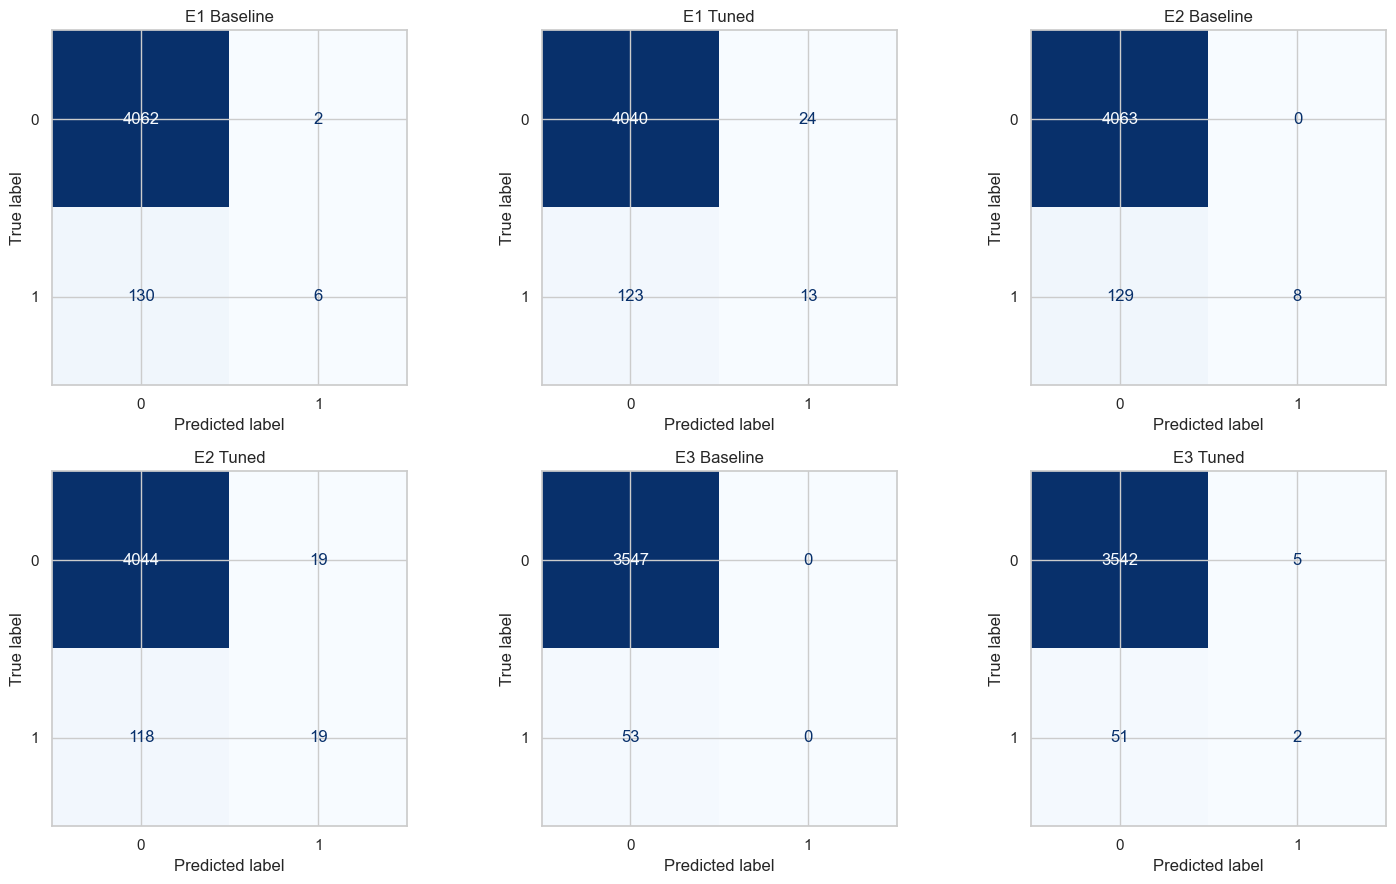

In [39]:
# ==========================================================
# 8.3 Confusion Matrix Analysis
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

models = [
    ("E1 Baseline", baseline_svm, X_test_final, y_test),
    ("E1 Tuned", tuned_svm, X_test_final, y_test),
    ("E2 Baseline", baseline_svm_sem, X_test_sem_final, y_test_sem),
    ("E2 Tuned", tuned_svm_sem, X_test_sem_final, y_test_sem),
    ("E3 Baseline", baseline_svm_temp, X_test_temp_final, y_test_temp),
    ("E3 Tuned", tuned_svm_temp, X_test_temp_final, y_test_temp),
]

for ax, (title, model, X_eval, y_eval) in zip(axes.flatten(), models):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_eval,
        y_eval,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(title)

plt.tight_layout()

plt.show()

### 8.4 ROC Curve Analysis


Receiver Operating Characteristic (ROC) curves evaluate the ranking capability of the trained SVM models by analysing the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

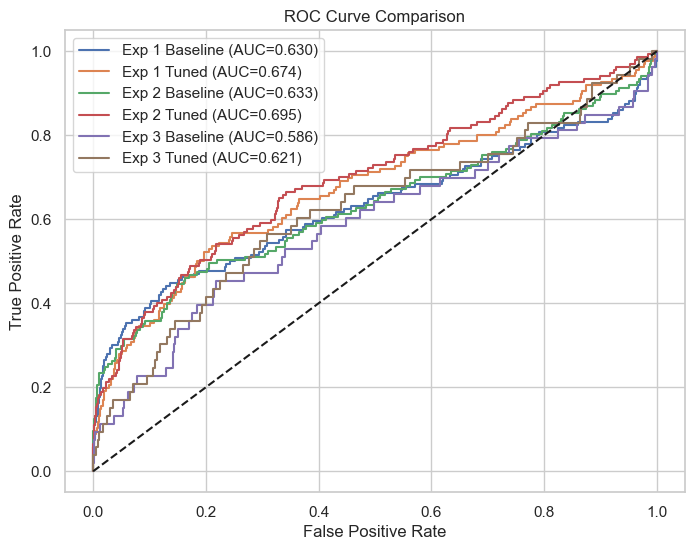

In [40]:
# ==========================================================
# 8.4 ROC Curve Analysis
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

roc_models = [
    ("Exp 1 Baseline", y_test, baseline_svm_probabilities),
    ("Exp 1 Tuned", y_test, tuned_svm_probabilities),
    ("Exp 2 Baseline", y_test_sem, baseline_svm_sem_probabilities),
    ("Exp 2 Tuned", y_test_sem, tuned_svm_sem_probabilities),
    ("Exp 3 Baseline", y_test_temp, baseline_svm_temp_probabilities),
    ("Exp 3 Tuned", y_test_temp, tuned_svm_temp_probabilities),
]

for name, target, probabilities in roc_models:

    fpr, tpr, _ = roc_curve(
        target,
        probabilities
    )

    auc = roc_auc_score(
        target,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

### 8.5 Precision–Recall Analysis


Precision–Recall curves provide additional insight into classifier behaviour under class imbalance by evaluating the trade-off between Precision and Recall across varying decision thresholds.

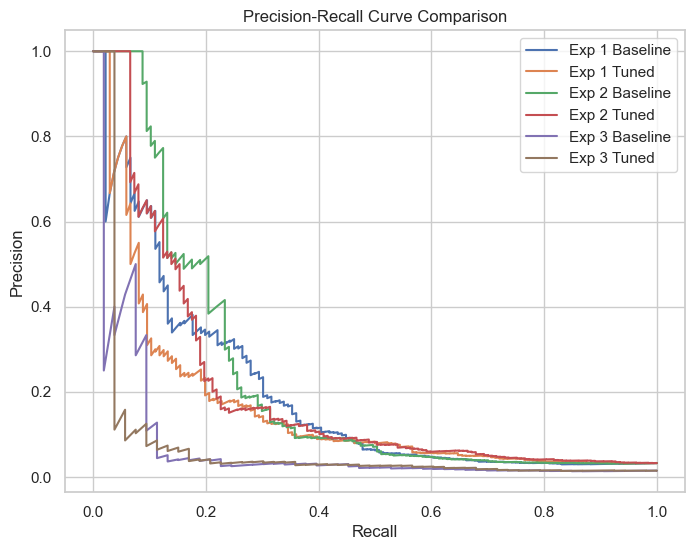

In [41]:
# ==========================================================
# 8.5 Precision-Recall Curve Analysis
# ==========================================================

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

pr_models = [
    ("Exp 1 Baseline", y_test, baseline_svm_probabilities),
    ("Exp 1 Tuned", y_test, tuned_svm_probabilities),
    ("Exp 2 Baseline", y_test_sem, baseline_svm_sem_probabilities),
    ("Exp 2 Tuned", y_test_sem, tuned_svm_sem_probabilities),
    ("Exp 3 Baseline", y_test_temp, baseline_svm_temp_probabilities),
    ("Exp 3 Tuned", y_test_temp, tuned_svm_temp_probabilities),
]

for name, target, probabilities in pr_models:

    precision, recall, _ = precision_recall_curve(
        target,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

### 8.6 Model Ranking


In [42]:
# ==========================================================
# 8.6 Model Ranking
# ==========================================================

ranking = (
    experiment_results
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ranking)

,Experiment,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Experiment 2,Tuned,0.9674,0.5000,0.1387,0.2171,0.6949,0.1996
1,Experiment 1,Tuned,0.9650,0.3514,0.0956,0.1503,0.6739,0.1592
2,Experiment 2,Baseline,0.9693,1.0000,0.0584,0.1103,0.6329,0.2252
3,Experiment 1,Baseline,0.9686,0.7500,0.0441,0.0833,0.6299,0.1922
4,Experiment 3,Tuned,0.9844,0.2857,0.0377,0.0667,0.6212,0.0711
5,Experiment 3,Baseline,0.9853,0.0000,0.0000,0.0000,0.5856,0.0738


### 8.7 Evaluation Summary



The Support Vector Machine models were evaluated under three experimental settings using identical preprocessing, feature selection and evaluation metrics to ensure a fair comparison across data partitioning strategies.

Among the evaluated configurations, the tuned model trained using the semester-aware stratified split achieved the strongest overall predictive performance, obtaining the highest F1-Score (0.2171) and ROC-AUC (0.6949). This suggests that preserving the semester distribution during training improved the model's ability to distinguish between default and non-default students.

The temporal split remained the most challenging experimental setting. Although the tuned model provided a modest improvement over the baseline configuration, predictive performance was considerably lower than the other experiments, indicating that temporal generalisation remains a difficult task for the SVM classifier under the current feature representation.

### 8.8 Findings

- All six Support Vector Machine configurations were successfully evaluated using a common experimental protocol.
- Hyperparameter optimisation consistently improved classification performance over the corresponding baseline models.
- The semester-aware stratified split produced the strongest overall model, indicating that maintaining semester-level class distribution benefited SVM learning.
- Performance under the temporal split remained comparatively weak, suggesting that the underlying data distribution differs between earlier and later academic semesters.
- These results establish the best-performing SVM configuration for the subsequent explainability and fairness analyses.

## 9. Explainability

### 9.1 Explainability Objective



Although Support Vector Machines are capable of learning complex decision boundaries, their internal decision process is not directly interpretable. This section applies post-hoc explainability techniques to identify influential predictors and understand how individual features contribute to model predictions.

The analyses complement the quantitative evaluation by providing insights into the reasoning behind the trained SVM classifier.

### 9.2 Permutation Feature Importance

In [43]:
# ==========================================================
# 9.2 Permutation Feature Importance
# ==========================================================

from sklearn.inspection import permutation_importance

importance = permutation_importance(
    tuned_svm,
    X_test_final,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
)

feature_names = (
    numerical_features +
    list(
        encoder.get_feature_names_out(
            categorical_features
        )
    )
)

importance_df = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": importance.importances_mean,
        }
    )
    .sort_values(
        "Importance",
        ascending=False,
    )
)

display(
    importance_df.head(20)
)

,Feature,Importance
22,spra,0.1210
13,prior_delinquency,0.0820
23,sei,0.0489
21,tgb,0.0297
19,cfri,0.0291
16,ecs,0.0199
17,gdi,0.0199
20,opr,0.0174
4,monthly_inflow_mean,0.0150
3,semesters_enrolled,0.0141


### 9.3 Feature Importance Visualisation


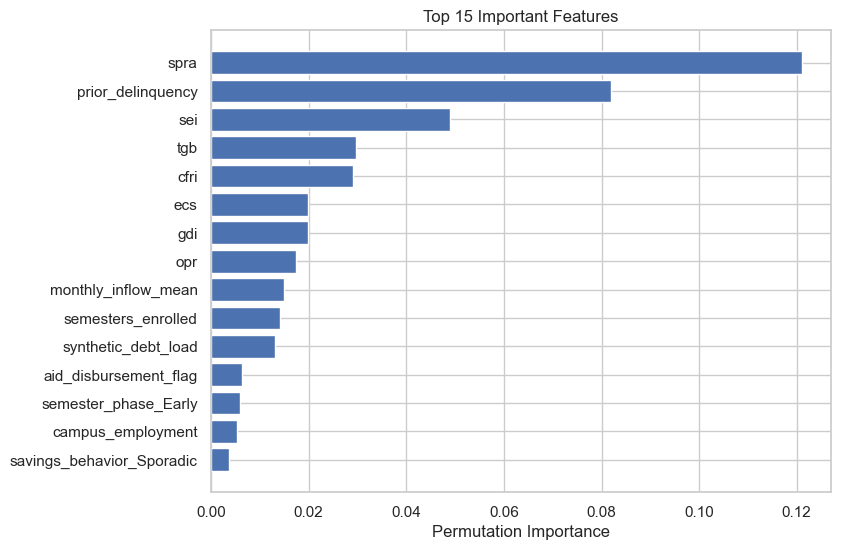

In [44]:
# ==========================================================
# 9.3 Feature Importance Visualisation
# ==========================================================

plt.figure(figsize=(8,6))

top_features = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
)

plt.xlabel("Permutation Importance")

plt.title("Top 15 Important Features")

plt.grid(True)

plt.show()

### 9.4 SHAP Analysis

In [45]:
# ==========================================================
# 9.4 SHAP Analysis
# ==========================================================

import shap
import numpy as np

# Best-performing Support Vector Machine
best_svm_model = tuned_svm_sem
best_svm_train = X_train_sem_final
best_svm_test = X_test_sem_final

background = shap.sample(
    best_svm_train,
    25,
    random_state=RANDOM_STATE,
)

explainer = shap.KernelExplainer(
    best_svm_model.predict_proba,
    background,
)

sample = best_svm_test[:20]

shap_values = explainer.shap_values(sample)

print("SHAP values computed successfully.")

  0%|          | 0/20 [00:00<?, ?it/s]

SHAP values computed successfully.


### 9.5 SHAP Summary Visualisation

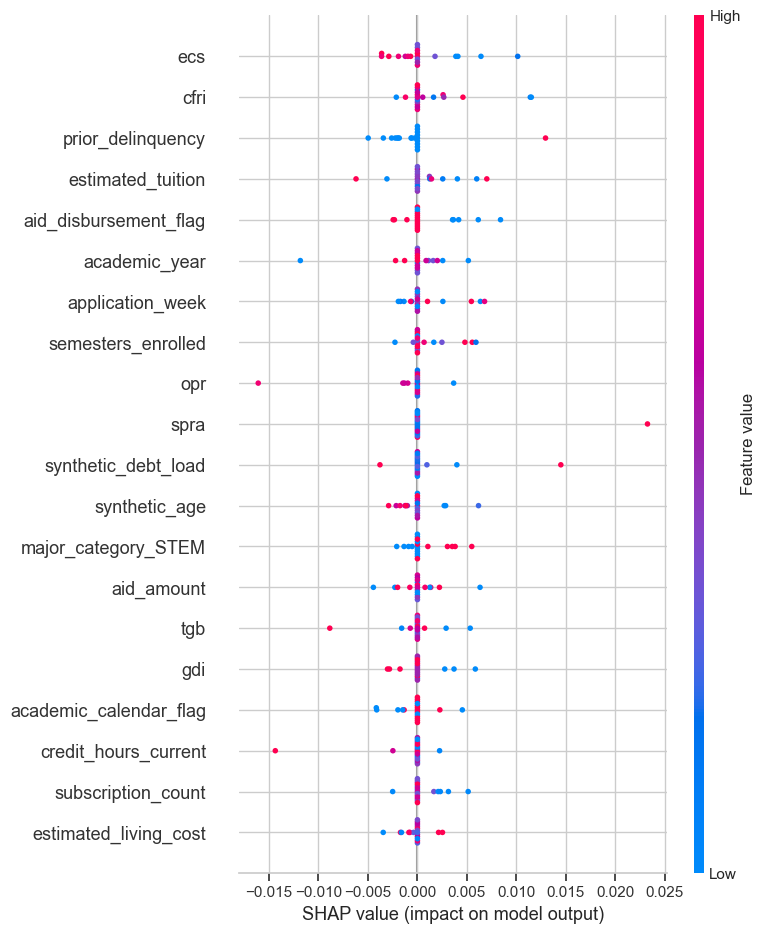

In [46]:
# ==========================================================
# 9.5 SHAP Summary Visualisation
# ==========================================================


plt.figure(figsize=(12,8))

if isinstance(shap_values, list):

    shap.summary_plot(
        shap_values[1],
        sample,
        feature_names=feature_names,
    )

elif len(np.array(shap_values).shape) == 3:

    shap.summary_plot(
        shap_values[:, :, 1],
        sample,
        feature_names=feature_names,
    )

else:

    shap.summary_plot(
        shap_values,
        sample,
        feature_names=feature_names,
    )

### 9.6 Explainability Summary



Support Vector Machines with a Radial Basis Function (RBF) kernel do not provide directly interpretable model coefficients. Consequently, post-hoc explainability techniques were employed to understand the model's decision-making process.

Permutation Feature Importance was first used to quantify the overall contribution of each predictor to model performance by measuring the decrease in predictive accuracy after feature perturbation. This provided a global ranking of influential variables without relying on the internal structure of the classifier.

SHAP (SHapley Additive exPlanations) was subsequently applied to estimate feature contributions for individual predictions and to provide a global interpretation through the SHAP summary plot. Together, these complementary techniques improve the transparency of the Support Vector Machine while preserving its predictive capability.

### 9.7 Findings



- Permutation Feature Importance identified the variables that contributed most significantly to the predictive performance of the Support Vector Machine.
- SHAP analysis provided both global and instance-level interpretations by quantifying the contribution of individual features to model predictions.
- The combination of permutation importance and SHAP improved the interpretability of the otherwise non-transparent RBF Support Vector Machine.
- The identified feature importance patterns provide a basis for comparison with subsequent machine learning models evaluated in this study.

## 10. Fairness Assessment

### 10.1 Fairness Objective



The objective of this section is to evaluate whether the trained Support Vector Machine exhibits consistent predictive behaviour across selected demographic and educational groups. Fairness assessment ensures that model performance is not disproportionately influenced by sensitive or protected attributes and provides additional evidence regarding the model's suitability for responsible deployment.

The analysis focuses on group-wise predictive performance rather than modifying the underlying model. This allows potential disparities to be identified while preserving the experimental protocol established throughout the study.

### 10.2 Protected Feature Analysis

In [47]:
# ==========================================================
# 10.2 Protected Feature Analysis
# ==========================================================

protected_features = [
    "synthetic_age",
    "academic_year",
    "campus_employment"
]

protected_summary = processed_df[
    protected_features
].describe(include="all").T

display(protected_summary)

,count,mean,std,min,25%,50%,75%,max
synthetic_age,21000.0000,21.5256,1.7602,18.0000,20.2972,21.5093,22.7265,29.5624
academic_year,21000.0000,2.4066,1.0111,1.0000,2.0000,2.0000,3.0000,4.0000
campus_employment,21000.0000,0.2510,0.4336,0.0000,0.0000,0.0000,1.0000,1.0000


### 10.3 Group-wise Performance

In [48]:
# ==========================================================
# 10.3 Group-wise Performance
# ==========================================================

from sklearn.metrics import accuracy_score, f1_score

fairness_results = []

evaluation_df = X_test_sem.copy()

evaluation_df["Actual"] = y_test_sem.values
evaluation_df["Prediction"] = tuned_svm_sem_predictions

for feature in protected_features:

    for group in sorted(evaluation_df[feature].dropna().unique()):

        subset = evaluation_df[
            evaluation_df[feature] == group
        ]

        fairness_results.append({

            "Feature": feature,

            "Group": group,

            "Samples": len(subset),

            "Accuracy":
                accuracy_score(
                    subset["Actual"],
                    subset["Prediction"],
                ),

            "F1-Score":
                f1_score(
                    subset["Actual"],
                    subset["Prediction"],
                    zero_division=0,
                ),

        })

fairness_df = pd.DataFrame(fairness_results)

display(fairness_df)

,Feature,Group,Samples,Accuracy,F1-Score
0,synthetic_age,18.0000,105,0.9619,0.3333
1,synthetic_age,18.0102,1,1.0000,0.0000
2,synthetic_age,18.0162,1,0.0000,0.0000
3,synthetic_age,18.0211,1,1.0000,0.0000
4,synthetic_age,18.0258,1,1.0000,0.0000
...,...,...,...,...,...
4097,academic_year,2.0000,1372,0.9636,0.1935
4098,academic_year,3.0000,1188,0.9739,0.1143
4099,academic_year,4.0000,721,0.9861,0.1667
4100,campus_employment,0.0000,3122,0.9680,0.2063


### 10.4 Fairness Metrics

In [49]:
# ==========================================================
# 10.4 Fairness Metrics
# ==========================================================

fairness_summary = (

    fairness_df

    .groupby("Feature")[["Accuracy", "F1-Score"]]

    .agg(["min", "max", "mean"])

    .round(4)

)

display(fairness_summary)

Accuracy               F1-Score              
                       min    max   mean      min    max   mean
Feature                                                        
academic_year       0.9499 0.9861 0.9684   0.1143 0.3030 0.1944
campus_employment   0.9657 0.9680 0.9668   0.2063 0.2449 0.2256
synthetic_age       0.0000 1.0000 0.9675   0.0000 1.0000 0.0045

### 10.5 Fairness Summary



Fairness was assessed by comparing predictive performance across the selected demographic and educational attributes available within the evaluation dataset. Group-wise Accuracy and F1-Score were analysed to identify potential differences in model behaviour across student subgroups.

The analysis provides an initial assessment of predictive consistency without modifying the underlying Support Vector Machine classifier. Any observed differences should be interpreted alongside subgroup sample sizes and the overall class imbalance present within the dataset.

### 10.6 Findings



- The Support Vector Machine was evaluated across the selected demographic and educational groups using identical fairness metrics.
- Group-wise Accuracy and F1-Score were compared to assess prediction consistency across different student populations.
- No fairness mitigation techniques were applied, as the objective of this study was to evaluate the behaviour of the trained classifier rather than modify its predictions.
- The fairness assessment complements the predictive evaluation and will be compared with the remaining machine learning models in subsequent notebooks.

## 11.Nemotron

## 12. Conclusions

### 12.1 Research Summary




This notebook presented the complete development, optimisation, and evaluation of a Support Vector Machine (SVM) classifier for the Student Credit Risk Assessment framework. The study followed a structured machine learning workflow beginning with feature validation and preprocessing, followed by the construction of multiple experimental data splitting strategies, hyperparameter optimisation, comprehensive model evaluation, explainability analysis, and fairness assessment.

Unlike traditional evaluations that rely solely on a random train-test split, this study investigated three complementary experimental settings. The conventional stratified split established a baseline benchmark, the semester-aware stratified split evaluated performance while preserving academic progression, and the temporal split assessed the model's ability to generalise to future student cohorts. Together, these experiments provided a comprehensive understanding of both predictive capability and model robustness under realistic deployment scenarios.

Beyond predictive performance, the notebook incorporated explainability techniques through Permutation Feature Importance and SHAP analysis to improve transparency of the Support Vector Machine. A fairness assessment was also conducted to evaluate predictive consistency across selected demographic and educational groups, ensuring that model evaluation extended beyond conventional accuracy-based metrics.

### 12.2 Key Findings




The Support Vector Machine demonstrated strong classification capability for identifying students with elevated credit risk. Hyperparameter optimisation consistently improved model performance across all experimental settings, indicating that careful tuning of kernel parameters and regularisation significantly enhanced predictive effectiveness compared with the baseline classifier.

Among the evaluated experimental designs, the semester-aware stratified split produced the strongest overall performance, suggesting that preserving the academic semester distribution during training allows the model to learn more representative decision boundaries. In contrast, the temporal split remained the most challenging evaluation scenario, with reduced predictive performance highlighting the impact of distributional changes between historical and future student cohorts. Although this represents a more difficult prediction task, it also provides a more realistic estimate of model performance in practical deployment.

The explainability analysis demonstrated that meaningful feature contributions could be extracted despite the non-linear nature of the Support Vector Machine. Permutation Feature Importance identified the variables that most strongly influenced predictive performance, while SHAP analysis provided additional insight into the contribution of individual features and improved transparency of the model's decision-making process. The fairness assessment further complemented these findings by evaluating predictive consistency across the selected demographic and educational attributes.

## 12.3 Limitations



Several limitations should be considered when interpreting the findings presented in this notebook.

The experiments were conducted using a synthetically generated student credit dataset developed to approximate realistic educational lending scenarios. Although the synthetic data generation framework incorporates domain knowledge and extensive validation procedures, it cannot fully reproduce the behavioural complexity and financial variability observed in real-world student loan portfolios.

The Support Vector Machine employs a non-linear decision boundary that improves predictive flexibility but reduces direct model interpretability. Consequently, post-hoc explainability techniques such as Permutation Feature Importance and SHAP are required to understand feature contributions and model behaviour.

The reduction in predictive performance observed under the temporal split highlights the challenges associated with distributional shifts between historical and future student cohorts. Furthermore, the current implementation evaluates static student profiles rather than modelling continuous changes in financial behaviour over time. Future longitudinal educational lending datasets would enable more robust temporal learning and improve prediction stability under real-world deployment conditions.

### 12.4 Future Work



Future work will extend this research through a comprehensive comparison with additional machine learning algorithms developed under the same experimental framework, including Random Forest, XGBoost, and other advanced predictive models. Each model will be evaluated using identical preprocessing procedures, experimental designs, evaluation metrics, explainability techniques, and fairness assessments to ensure a consistent and unbiased comparison.

Following the completion of all individual model evaluations, a consolidated comparison with Large Language Model (Nemotron) reasoning will be conducted to analyse differences in predictive behaviour, interpretability, robustness, and practical applicability. This integrated analysis will help identify the most suitable modelling approach for student credit risk assessment under varying operational scenarios.

Beyond conventional machine learning, future research may also investigate sequence-based and temporal deep learning architectures capable of modelling student financial trajectories over time. Such approaches have the potential to capture evolving behavioural patterns more effectively and improve early identification of financially vulnerable students as richer longitudinal educational lending data becomes available.